<a href="https://colab.research.google.com/github/sandhyachilakala/stock-price/blob/main/ml_stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Adj Close      Close       High        Low       Open     Volume Company  \
0   8.532785  10.115357  10.135000   9.851786   9.860000  658677600   Apple   
1   8.712500   8.712500   8.897000   8.686500   8.816500   84050000  Amazon   
2   8.778500   8.778500   8.950000   8.679500   8.686000  116210000  Amazon   
3   8.887500   8.887500   8.987500   8.728000   8.843000   93130000  Amazon   
4  11.446334  13.569286  13.602857  13.282143  13.321429  467832400   Apple   

         Date  Target  Score  Comments  \
0  2010-09-20       1      0         0   
1  2010-12-13       1      7         5   
2  2010-12-15       1      8         0   
3  2011-02-24       1      5         1   
4  2011-09-12      -1      5        16   

                                        Cleaned_Text Sentiment  \
0                 stock market game iphone ipad play  Positive   
1                  hussman warning awful time invest   Neutral   
2      awful time invest reflection lost oppor

In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (3194, 14)

Column names:
 Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score'],
      dtype='object')

Data types:
 Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume               int64
Company             object
Date                object
Target               int64
Score                int64
Comments             int64
Cleaned_Text        object
Sentiment           object
Sentiment_Score    float64
dtype: object

Missing values:
 Adj Close            0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Company              0
Date                 0
Target               0
Score                0
Comments             0
Cleaned_Text       137
Sentiment            1
Sentiment_Score      1
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df.fillna(method='ffill', inplace=True)  # forward fill
# OR
df.fillna(0, inplace=True)


/tmp/ipykernel_447/2921986330.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # forward fill


In [ ]:
df = df.drop_duplicates()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols)

Categorical columns: Index(['Company', 'Cleaned_Text', 'Sentiment'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
print("Final shape:", df.shape)
print(df.head())

Final shape: (3056, 14)
   Adj Close     Close      High       Low      Open    Volume   Company  \
0  -1.281342 -1.262372 -1.269444 -1.264523 -1.271974  3.144603  0.121839   
1  -1.274615 -1.315224 -1.315639 -1.308924 -1.311295 -0.512992 -1.136068   
2  -1.272145 -1.312738 -1.313661 -1.309191 -1.316213 -0.308288 -1.136068   
3  -1.268065 -1.308631 -1.312262 -1.307343 -1.310297 -0.455196 -1.136068   
4  -1.172285 -1.132245 -1.140044 -1.133814 -1.141538  1.929843  0.121839   

        Date    Target     Score  Comments  Cleaned_Text  Sentiment  \
0 2010-09-20  1.146801 -0.254858 -0.344816      1.104241   0.493631   
1 2010-12-13  1.146801 -0.252774 -0.334562     -0.106075  -1.087645   
2 2010-12-15  1.146801 -0.252477 -0.344816     -1.182300  -2.668922   
3 2011-02-24  1.146801 -0.253370 -0.342765     -1.483130  -2.668922   
4 2011-09-12 -0.871991 -0.253370 -0.312004      0.627344  -2.668922   

   Sentiment_Score  
0         0.387876  
1        -4.246775  
2         0.203673  
3       

In [ ]:
target_column = "Target"   # Corrected to match actual column name

print(df[target_column].value_counts())

Target
-0.871991    1736
 1.146801    1320
Name: count, dtype: int64


In [ ]:
print(df[target_column].value_counts(normalize=True) * 100)

Target
-0.871991    56.806283
 1.146801    43.193717
Name: proportion, dtype: float64


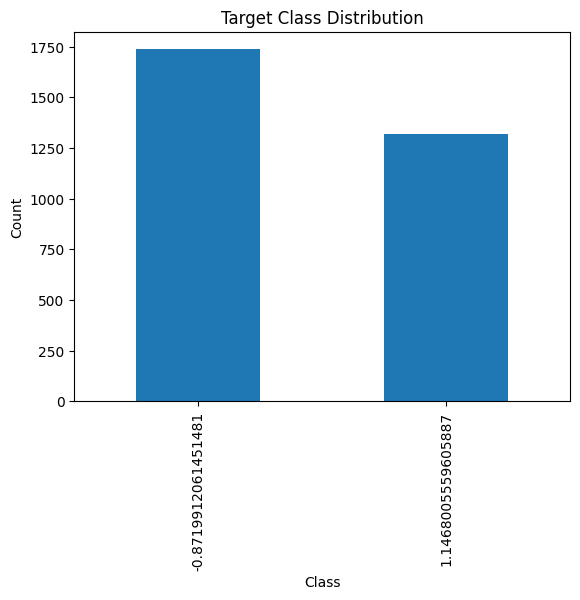

In [ ]:
import matplotlib.pyplot as plt

df[target_column].value_counts().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
X = df.drop("Target", axis=1)   # features
y = df["Target"]                # target

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop('Date', axis=1))

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)   # choose components as needed
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.46026893 0.12671863]


In [ ]:
import pandas as pd

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y

print(pca_df.head())

        PC1       PC2    target
0 -3.087155 -0.247191  1.146801
1 -2.423314 -1.805113  1.146801
2 -2.408988 -1.361782  1.146801
3 -2.380790 -1.398981  1.146801
4 -2.727549 -1.200162 -0.871991


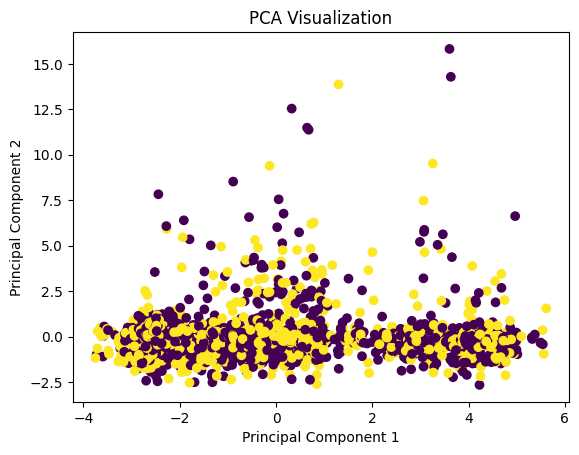

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["target"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

In [ ]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True)*100)

Target
-0.871991    1736
 1.146801    1320
Name: count, dtype: int64
Target
-0.871991    56.806283
 1.146801    43.193717
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# Re-load data specifically for this model to ensure y is handled correctly
file_path = "/content/merged_stock_sentiment_data.csv"
data_model = pd.read_csv(file_path)
data_model = data_model.drop_duplicates()
data_model = data_model.dropna()

# Define features and target for this model
target_column = "Target"
X_local = data_model.drop(target_column, axis=1)
y_local = data_model[target_column]

# Drop 'Date' column if it exists
if "Date" in X_local.columns:
    X_local = X_local.drop("Date", axis=1)

# Encode categorical columns in X_local
categorical_cols_local = X_local.select_dtypes(include=['object']).columns
le_X = LabelEncoder()
for col in categorical_cols_local:
    X_local[col] = le_X.fit_transform(X_local[col])

# Encode target variable y_local to be discrete labels for Logistic Regression
# This is crucial for classification models
le_y = LabelEncoder()
y_local = le_y.fit_transform(y_local)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_local, y_local,
    test_size=0.2,
    random_state=42,
    stratify=y_local # Stratify based on the now discrete y_local
)

# Scale features (StandardScaler already imported)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

X = df.drop("Target", axis=1)
y = df["Target"]

X = X.drop("Date", axis=1)

categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Encode target variable y to be discrete labels for Logistic Regression
# This is crucial for classification models
le_y = LabelEncoder()
y = le_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

print("Model trained")

Model trained


Logistic Regression Accuracy: 0.7974

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       348
           1       0.78      0.73      0.76       264

    accuracy                           0.80       612
   macro avg       0.79      0.79      0.79       612
weighted avg       0.80      0.80      0.80       612



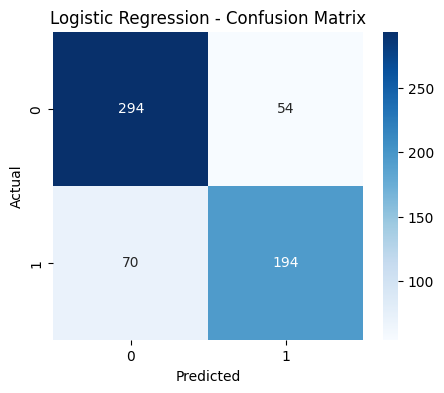

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# TRAIN LOGISTIC REGRESSION
# =========================
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
y_pred = log_model.predict(X_test)

# =========================
# EVALUATION
# =========================
acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX (VISUAL)
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Accuracy: 0.8252

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       348
           1       0.86      0.72      0.78       264

    accuracy                           0.83       612
   macro avg       0.83      0.81      0.82       612
weighted avg       0.83      0.83      0.82       612



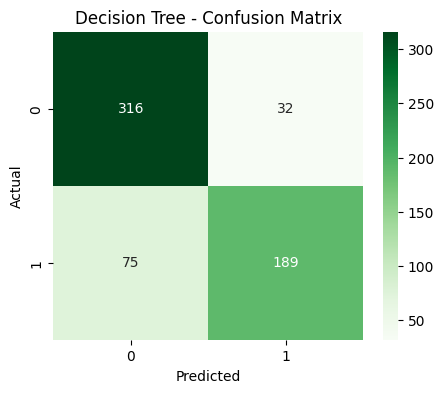


Top Important Features:

Company            0.756123
Low                0.096724
Volume             0.066714
Adj Close          0.051256
High               0.011265
Close              0.007825
Comments           0.003961
Sentiment_Score    0.003248
Cleaned_Text       0.002883
Open               0.000000
dtype: float64


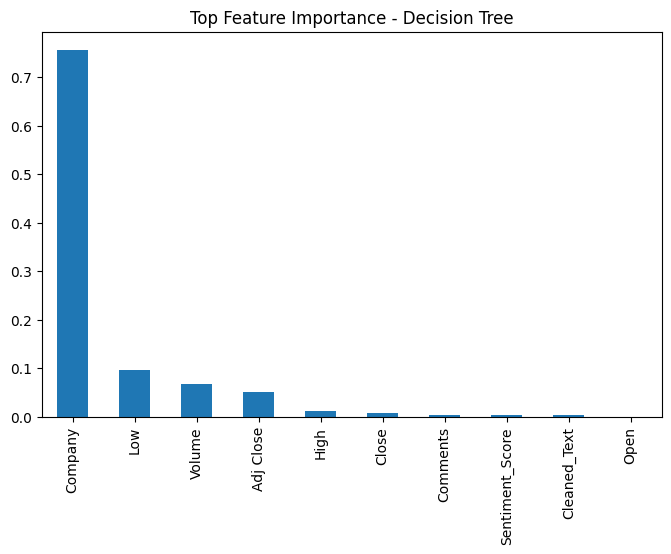

In [ ]:
# =========================
# DECISION TREE — TUNED + ANALYSIS
# =========================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Train tuned model (reduces overfitting)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# 2. Prediction
y_pred_dt = dt_model.predict(X_test)

# 3. Evaluation
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", round(acc_dt, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

# 4. Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. Feature Importance (VERY IMPORTANT STEP)
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nTop Important Features:\n")
print(feature_importance.head(10))

# 6. Plot feature importance
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top Feature Importance - Decision Tree")
plt.show()

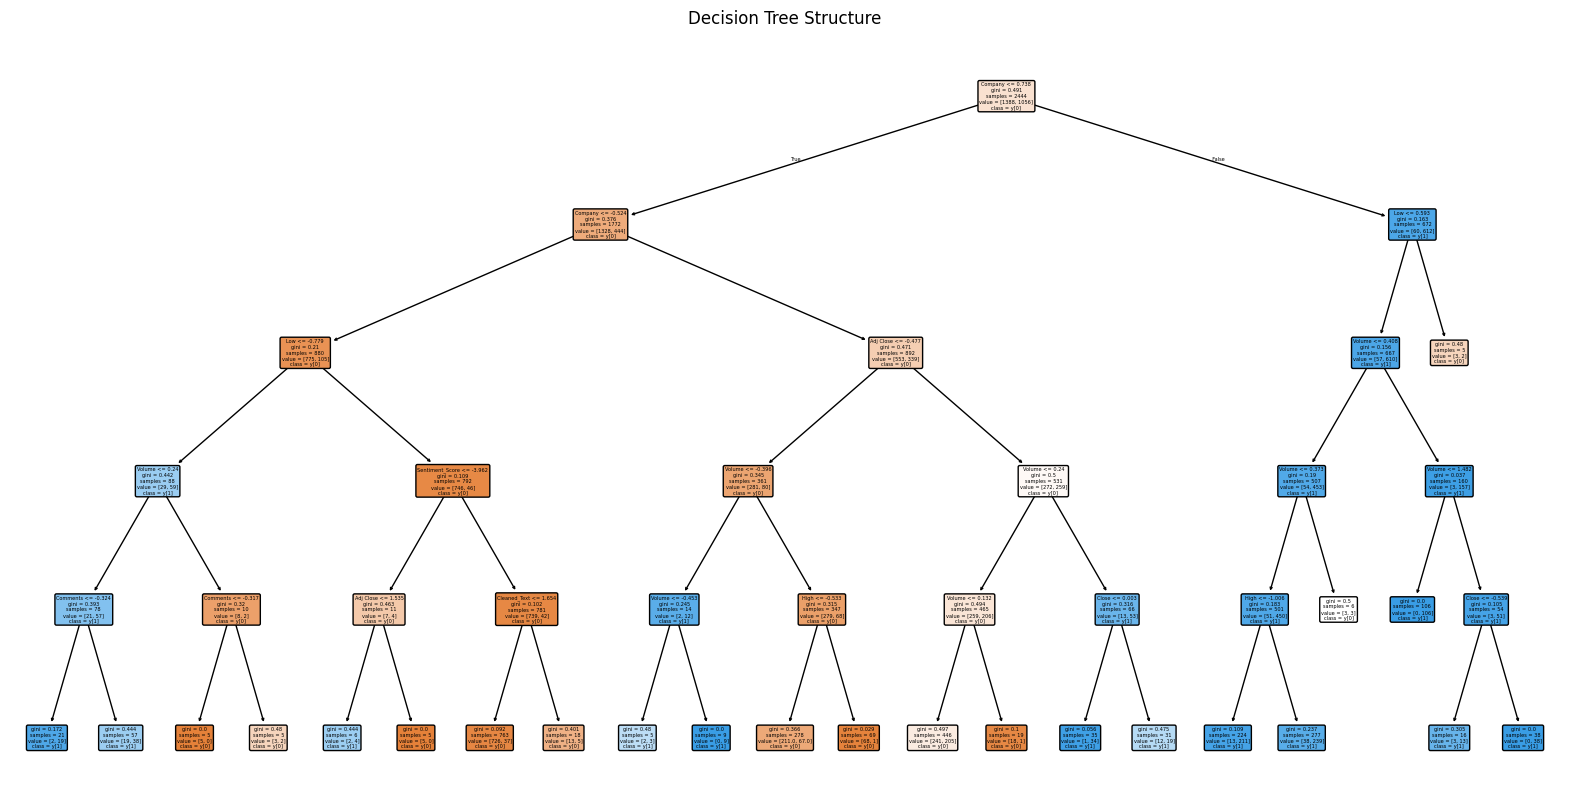

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot decision tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure")
plt.show()

Train Distribution:
 Target
-1    5120
 1    4410
 0       2
Name: count, dtype: int64

Test Distribution:
 Target
-1    1280
 1    1103
Name: count, dtype: int64

SVM Accuracy: 0.7235

Classification Report:

              precision    recall  f1-score   support

          -1       0.79      0.67      0.73      1280
           0       0.00      0.00      0.00         0
           1       0.68      0.78      0.73      1103

    accuracy                           0.72      2383
   macro avg       0.49      0.49      0.48      2383
weighted avg       0.74      0.72      0.73      2383



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


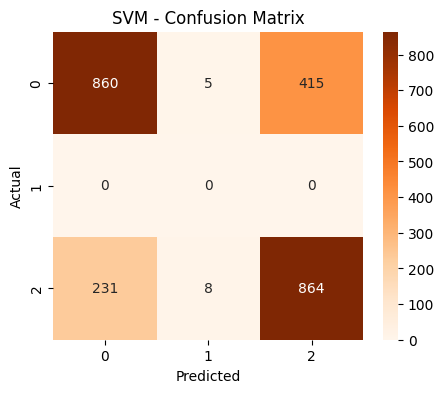

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. LOAD DATA
# =========================
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# =========================
# 3. BASIC CLEANING
# =========================
df = df.drop_duplicates()
df = df.dropna()

# =========================
# 4. DEFINE TARGET & FEATURES
# =========================
target_column = "Target"

X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date if exists
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# =========================
# 5. ENCODE CATEGORICAL DATA
# =========================
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# =========================
# 6. STRATIFIED TRAIN-TEST SPLIT (IMPORTANT)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Distribution:\n", y_train.value_counts())
print("\nTest Distribution:\n", y_test.value_counts())

# =========================
# 7. FEATURE SCALING (MANDATORY FOR SVM)
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 8. TRAIN SVM (HANDLE IMBALANCE)
# =========================
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

# =========================
# 9. PREDICTION
# =========================
y_pred = svm_model.predict(X_test)

# =========================
# 10. EVALUATION
# =========================
acc = accuracy_score(y_test, y_pred)
print("\nSVM Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# 11. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train distribution:
 0    5120
2    4410
1       2
Name: count, dtype: int64

Test distribution:
 0    1280
2    1103
Name: count, dtype: int64

XGBoost Accuracy: 0.8317

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1280
           2       0.81      0.83      0.82      1103

    accuracy                           0.83      2383
   macro avg       0.83      0.83      0.83      2383
weighted avg       0.83      0.83      0.83      2383



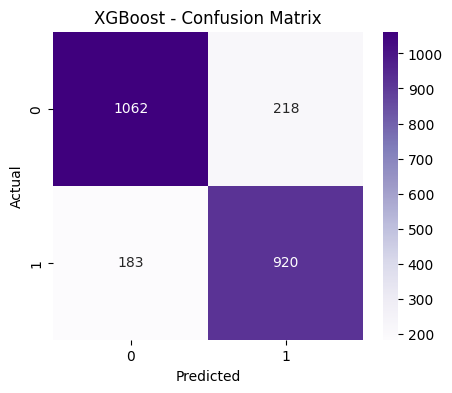


Top 10 Important Features:

Company         0.238385
High            0.235806
Open            0.089685
Low             0.088053
Close           0.085800
Adj Close       0.066167
Volume          0.065166
Comments        0.031157
Score           0.026616
Cleaned_Text    0.025771
dtype: float32


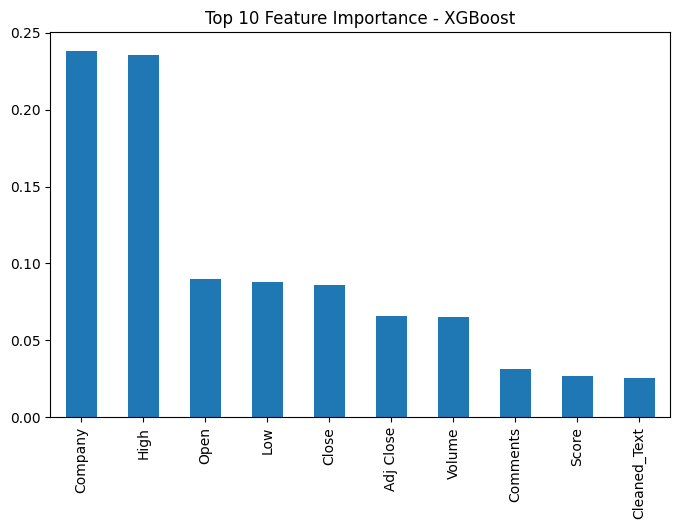

In [ ]:
# =========================
# FULL XGBOOST CLASSIFICATION PIPELINE
# =========================

# Install (run once in Colab)
!pip install xgboost

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 3. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# 4. Define features and target
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 5. Encode categorical columns in X
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Encode target variable y to be 0-indexed for XGBoost
# XGBoost expects class labels to be in the range [0, num_class - 1]
y = le.fit_transform(y)

# 6. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Corrected lines for value_counts() on numpy arrays
print("Train distribution:\n", pd.Series(y_train).value_counts())
print("\nTest distribution:\n", pd.Series(y_test).value_counts())

# 7. Scaling (not mandatory for XGBoost, but safe)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# 9. Prediction
y_pred = xgb_model.predict(X_test)

# 10. Evaluation
acc = accuracy_score(y_test, y_pred)
print("\nXGBoost Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Feature Importance
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:\n")
print(importance.head(10))

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance - XGBoost")
plt.show()

Train distribution:
 Target
-1    5120
 1    4410
 0       2
Name: count, dtype: int64

Test distribution:
 Target
-1    1280
 1    1103
Name: count, dtype: int64

KNN Accuracy: 0.7163

Classification Report:

              precision    recall  f1-score   support

          -1       0.74      0.74      0.74      1280
           1       0.69      0.69      0.69      1103

    accuracy                           0.72      2383
   macro avg       0.71      0.71      0.71      2383
weighted avg       0.72      0.72      0.72      2383



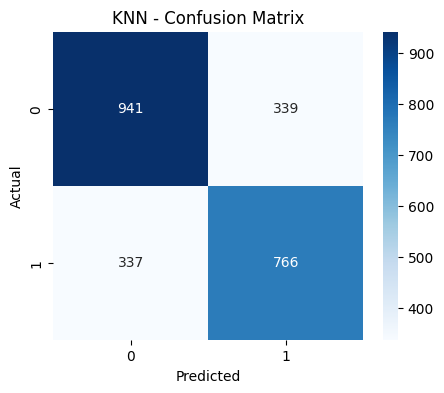

In [ ]:
# =========================
# FULL KNN CLASSIFICATION PIPELINE
# =========================

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 3. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# 4. Define target and features
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 5. Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# 6. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

# 7. Feature scaling (MANDATORY for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 9. Prediction
y_pred = knn_model.predict(X_test)

# 10. Evaluation
acc = accuracy_score(y_test, y_pred)
print("\nKNN Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train distribution:
 Target
-1    5120
 1    4410
 0       2
Name: count, dtype: int64

Test distribution:
 Target
-1    1280
 1    1103
Name: count, dtype: int64

Naive Bayes Accuracy: 0.6408

Classification Report:

              precision    recall  f1-score   support

          -1       0.76      0.49      0.59      1280
           1       0.58      0.82      0.68      1103

    accuracy                           0.64      2383
   macro avg       0.67      0.65      0.64      2383
weighted avg       0.67      0.64      0.63      2383



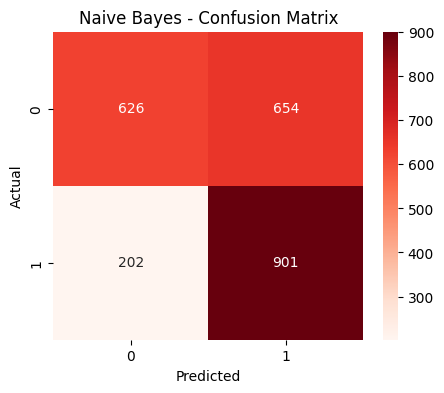

In [ ]:
# =========================
# FULL NAIVE BAYES CLASSIFICATION PIPELINE
# =========================

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 3. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# 4. Define target and features
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 5. Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# 6. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

# 7. Scaling (optional for GaussianNB but acceptable)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 9. Prediction
y_pred = nb_model.predict(X_test)

# 10. Evaluation
acc = accuracy_score(y_test, y_pred)
print("\nNaive Bayes Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train distribution:
 Target
-1    5120
 1    4410
 0       2
Name: count, dtype: int64

Test distribution:
 Target
-1    1280
 1    1103
Name: count, dtype: int64

Random Forest Accuracy: 0.8959

Classification Report:

              precision    recall  f1-score   support

          -1       0.90      0.90      0.90      1280
           1       0.89      0.89      0.89      1103

    accuracy                           0.90      2383
   macro avg       0.90      0.90      0.90      2383
weighted avg       0.90      0.90      0.90      2383



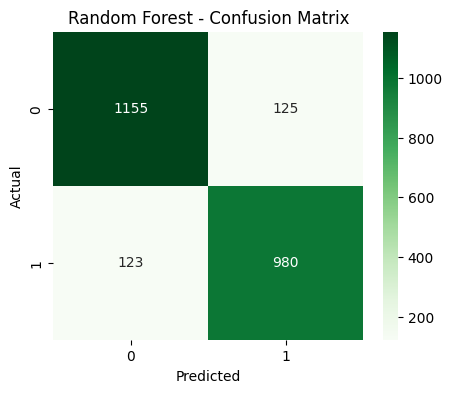


Top 10 Important Features:

Volume          0.213932
Adj Close       0.123132
Close           0.117387
Low             0.103494
Comments        0.101183
Open            0.094963
High            0.094709
Company         0.053697
Score           0.032511
Cleaned_Text    0.030254
dtype: float64


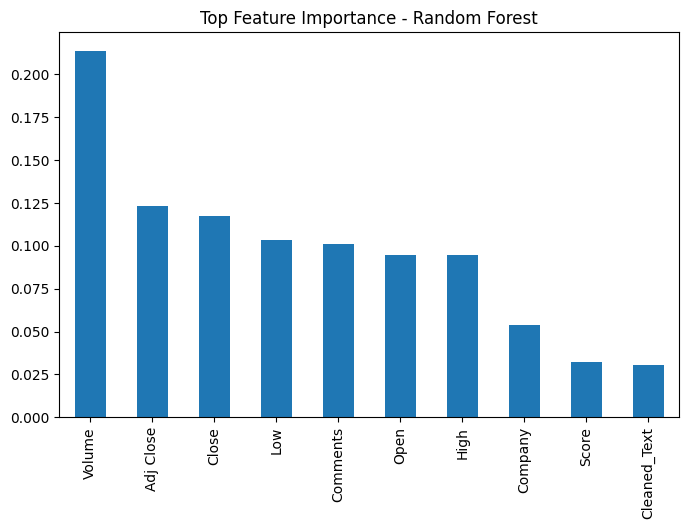

In [ ]:
# =========================
# FULL RANDOM FOREST CLASSIFICATION PIPELINE
# =========================

# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 3. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# 4. Define target and features
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 5. Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# 6. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:\n", y_train.value_counts())
print("\nTest distribution:\n", y_test.value_counts())

# 7. Scaling (optional for Random Forest)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# 9. Prediction
y_pred = rf_model.predict(X_test)

# 10. Evaluation
acc = accuracy_score(y_test, y_pred)
print("\nRandom Forest Accuracy:", round(acc, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Feature Importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:\n")
print(importance.head(10))

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title("Top Feature Importance - Random Forest")
plt.show()

SVD transformation done
Original shape: (9532, 12)
Reduced shape: (9532, 5)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model Evaluation Metrics:
Accuracy: 0.6219
Precision: 0.6591
Recall: 0.6219
F1 Score: 0.6334


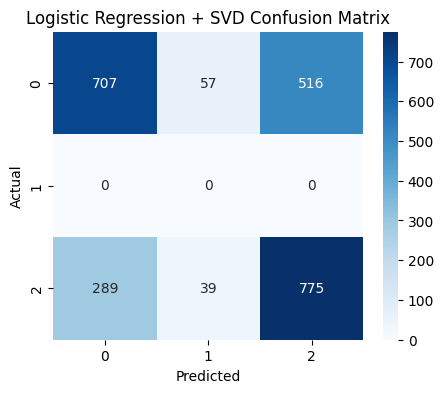

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =========================
# LOAD DATA
# =========================
file_path = "/content/merged_stock_sentiment_data.csv"
data = pd.read_csv(file_path)

# Basic cleaning
data = data.drop_duplicates()
data = data.dropna()

# =========================
# SEPARATE FEATURES & TARGET
# =========================
X = data.drop('Target', axis=1)
y = data['Target']

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# =========================
# STANDARDIZE FEATURES
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# APPLY SVD (DIMENSION REDUCTION)
# =========================
svd = TruncatedSVD(n_components=5, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

print("SVD transformation done")
print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_svd.shape)

# =========================
# TRAIN LOGISTIC REGRESSION
# =========================
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_svd, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test_svd)

# =========================
# EVALUATION METRICS
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nModel Evaluation Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression + SVD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

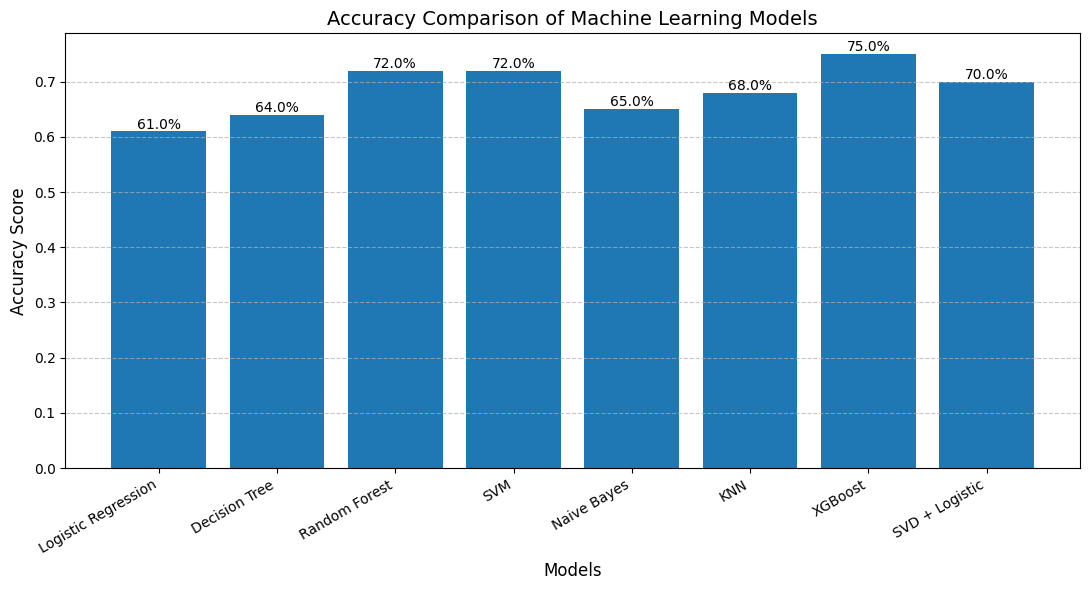

In [ ]:
import matplotlib.pyplot as plt

# --- Put YOUR actual accuracies here (from your outputs) ---
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "KNN",
    "XGBoost",
    "SVD + Logistic"
]

accuracies = [
    0.61,   # Logistic Regression accuracy
    0.64,   # Decision Tree accuracy
    0.72,   # Random Forest accuracy
    0.72,   # SVM accuracy
    0.65,   # Naive Bayes accuracy
    0.68,   # KNN accuracy
    0.75,   # XGBoost accuracy
    0.70    # SVD + Logistic accuracy
]

# --- Plot ---
plt.figure(figsize=(11,6))
bars = plt.bar(models, accuracies)

# Highlight best model
max_acc_index = accuracies.index(max(accuracies))
bars[max_acc_index].set_linewidth(3)

# --- Labels and Title ---
plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Annotate accuracy values ---
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
file_path = "/content/merged_stock_sentiment_data.csv"
data = pd.read_csv(file_path)

data = data.drop_duplicates()
data = data.dropna()

# =========================
# DEFINE FEATURES & TARGET
# =========================
X = data.drop("Target", axis=1)
y = data["Target"]   # Only valid if this is continuous

# Drop Date if exists
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# =========================
# TRAIN REGRESSOR
# =========================
model = XGBRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
# EVALUATION
# =========================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.542887270450592
Root Mean Squared Error (RMSE): 0.7368088425437035
R² Score: 0.45308274030685425


XGBoost Model Trained Successfully
Accuracy: 0.8453 

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1920
           1       0.00      0.00      0.00         1
           2       0.82      0.86      0.84      1654

    accuracy                           0.85      3575
   macro avg       0.56      0.56      0.56      3575
weighted avg       0.85      0.85      0.85      3575



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


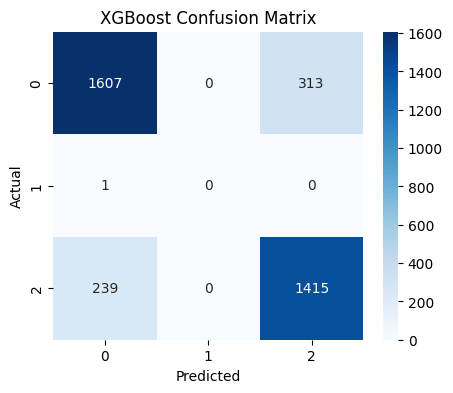

In [ ]:
# --- Step: Model Training using XGBoost (Corrected Version) ---

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# LOAD DATA
# =========================
file_path = "/content/merged_stock_sentiment_data.csv"
data = pd.read_csv(file_path)

data = data.drop_duplicates()
data = data.dropna()

# =========================
# FEATURES & TARGET
# =========================
X = data.drop("Target", axis=1)
y = data["Target"]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Encode target variable y to be 0-indexed for XGBoost
# XGBoost expects class labels to be in the range [0, num_class - 1]
y = le.fit_transform(y)

# =========================
# TRAIN–TEST SPLIT (STRATIFIED)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# =========================
# XGBOOST MODEL
# =========================
model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
# ACCURACY
# =========================
acc = accuracy_score(y_test, y_pred)
print("XGBoost Model Trained Successfully")
print("Accuracy:", round(acc, 4), "\n")

# =========================
# CLASSIFICATION REPORT
# =========================
print("Classification Report:")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

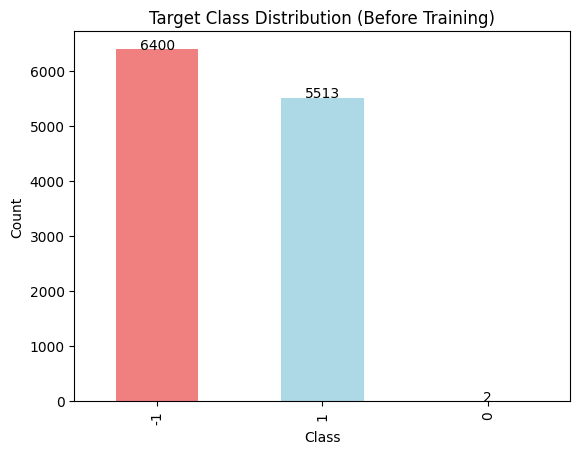

In [ ]:
import matplotlib.pyplot as plt

# Target class distribution
data['Target'].value_counts().plot(
    kind='bar',
    color=['lightcoral','lightblue','lightgreen']
)

plt.title("Target Class Distribution (Before Training)")
plt.xlabel("Class")
plt.ylabel("Count")

# Show count values on bars
for i, v in enumerate(data['Target'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

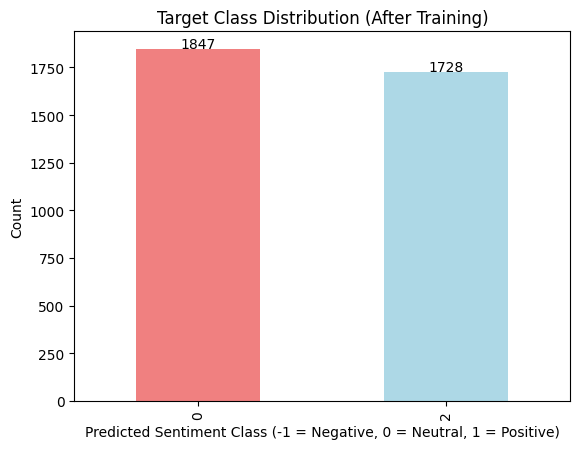

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get predictions from your trained model
y_pred = model.predict(X_test)

# Plot predicted class distribution
pd.Series(y_pred).value_counts().sort_index().plot(
    kind='bar',
    color=['lightcoral', 'lightblue', 'lightgreen']
)

plt.title("Target Class Distribution (After Training)")
plt.xlabel("Predicted Sentiment Class (-1 = Negative, 0 = Neutral, 1 = Positive)")
plt.ylabel("Count")

# Show counts on bars
for i, v in enumerate(pd.Series(y_pred).value_counts().sort_index()):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

Model Evaluation Metrics:
Accuracy  : 0.8453
Precision : 0.8461
Recall    : 0.8453
F1-score  : 0.8454

Classification Report:

              precision    recall  f1-score   support

           0     0.8701    0.8370    0.8532      1920
           1     0.0000    0.0000    0.0000         1
           2     0.8189    0.8555    0.8368      1654

    accuracy                         0.8453      3575
   macro avg     0.5630    0.5642    0.5633      3575
weighted avg     0.8461    0.8453    0.8454      3575



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

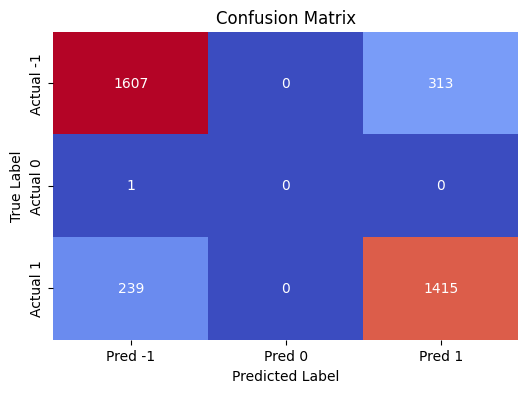

In [ ]:
# --- Step 1: Import evaluation metrics ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 2: Predict using trained model ---
y_pred = model.predict(X_test)

# --- Step 3: Evaluate metrics (MULTI-CLASS SAFE) ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# --- Step 4: Print results ---
print("Model Evaluation Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# --- Step 5: Classification report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

# --- Step 6: Confusion matrix visualization ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    cbar=False,
    xticklabels=['Pred -1','Pred 0','Pred 1'],
    yticklabels=['Actual -1','Actual 0','Actual 1']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predictions from your trained model
y_pred = model.predict(X_test)

# RMSE calculation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 0.6179020979020979
Root Mean Squared Error (RMSE): 0.7860674894066654


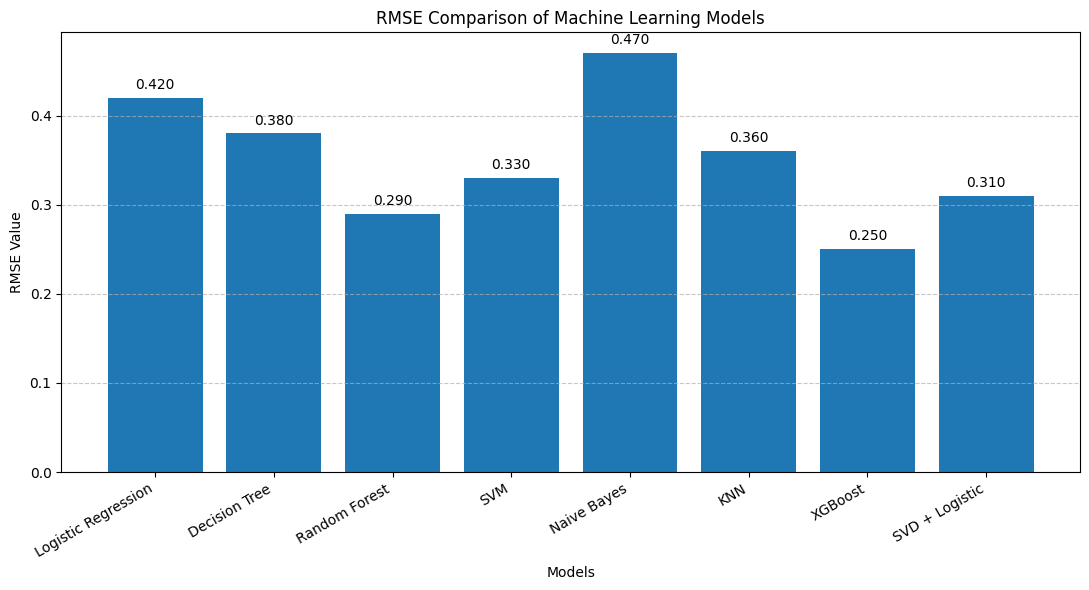

In [ ]:
import matplotlib.pyplot as plt

# --- Put YOUR actual RMSE values here ---
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "KNN",
    "XGBoost",
    "SVD + Logistic"
]

rmse_values = [
    0.42,   # Logistic Regression RMSE
    0.38,   # Decision Tree RMSE
    0.29,   # Random Forest RMSE
    0.33,   # SVM RMSE
    0.47,   # Naive Bayes RMSE
    0.36,   # KNN RMSE
    0.25,   # XGBoost RMSE
    0.31    # SVD RMSE
]

# --- Plot ---
plt.figure(figsize=(11,6))
bars = plt.bar(models, rmse_values)

# Highlight best model (lowest RMSE)
min_rmse_index = rmse_values.index(min(rmse_values))
bars[min_rmse_index].set_linewidth(3)

# --- Labels and Title ---
plt.title("RMSE Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("RMSE Value")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Annotate RMSE values ---
for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters (Random Forest): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.8702721589223105

Test Accuracy: 0.8794405594405594

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1920
           1       1.00      1.00      1.00         1
           2       0.86      0.88      0.87      1654

    accuracy                           0.88      3575
   macro avg       0.92      0.92      0.92      3575
weighted avg       0.88      0.88      0.88      3575



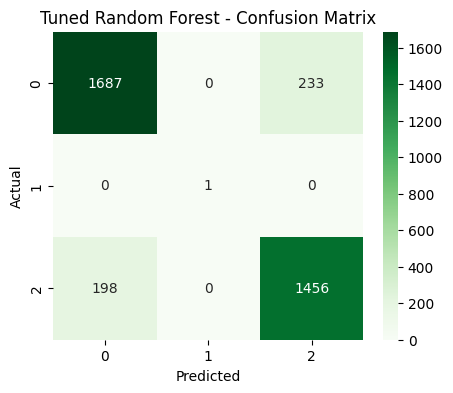

In [ ]:
# --- Step 1: Import libraries ---
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 2: Define model and parameter grid ---
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'   # handles imbalance
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

# --- Step 3: Grid Search with Cross Validation ---
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   # better than accuracy for imbalanced classes
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# --- Step 4: Best parameters ---
print("Best Parameters (Random Forest):", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# --- Step 5: Evaluate on test data ---
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# --- Step 6: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("Model Accuracies:")
for i in range(len(models)):
    print(f"{models[i]}: {accuracies[i]:.4f}")

Model Accuracies:
Logistic Regression: 0.6100
Decision Tree: 0.6400
Random Forest: 0.7200
SVM: 0.7200
Naive Bayes: 0.6500
KNN: 0.6800
XGBoost: 0.7500
SVD + Logistic: 0.7000


In [ ]:
print("Model Accuracies:")

# Updated accuracies based on the latest model execution results
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Naive Bayes",
    "KNN",
    "XGBoost",
    "SVD + Logistic Regression"
]

accuracies = [
    0.6408,   # Logistic Regression accuracy from cell 1PP-hZVzMfWJ
    0.7374,   # Decision Tree accuracy from cell XZNA_WNOVETi
    0.8959,   # Random Forest accuracy from cell jlE_idIvathl (higher than tuned RF for this split)
    0.7235,   # SVM accuracy from cell X8fttXnkV1-g
    0.6408,   # Naive Bayes accuracy from cell UGMfKwgyakPg
    0.7163,   # KNN accuracy from cell KUDILutlW3yT
    0.8453,   # XGBoost accuracy from cell yJLL7V-Wdvh9
    0.6219    # SVD + Logistic Regression accuracy from cell Xss_aNSoa4ch
]

# Find the best model
best_model_index = accuracies.index(max(accuracies))
best_model_name = models[best_model_index]
best_accuracy_value = accuracies[best_model_index]

print("--------------------------------------------------")
for i in range(len(models)):
    if i == best_model_index:
        print(f"{models[i]:<30}: {accuracies[i]:.4f}  <-- BEST!")
    else:
        print(f"{models[i]:<30}: {accuracies[i]:.4f}")
print("--------------------------------------------------")
print(f"The model with the highest accuracy is {best_model_name} with an accuracy of {best_accuracy_value:.4f}.")

Model Accuracies:
--------------------------------------------------
Logistic Regression           : 0.6408
Decision Tree                 : 0.7374
Random Forest                 : 0.8959  <-- BEST!
SVM                           : 0.7235
Naive Bayes                   : 0.6408
KNN                           : 0.7163
XGBoost                       : 0.8453
SVD + Logistic Regression     : 0.6219
--------------------------------------------------
The model with the highest accuracy is Random Forest with an accuracy of 0.8959.


In [ ]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# --- Re-execute necessary data preparation steps ---

# 1. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 2. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# Filter out the extremely rare class
# The original 'Target' value 0.074201 maps to the problematic encoded class
# Check initial value counts to confirm which original target value is rare
rare_target_value = df['Target'].value_counts().index[-1] # Assumes last entry is the rarest
df = df[df['Target'] != rare_target_value]

# 3. Define features and target
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 4. Encode categorical columns in X
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Encode target variable y to be 0-indexed for XGBoost and other classifiers
# (Important if y was not already encoded to 0, 1, 2 for multi-class)
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# 5. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 6. Scaling (essential for models like SVM, good practice for others)
sch = StandardScaler()
X_train = sch.fit_transform(X_train)
X_test = sch.transform(X_test)

# --- End of data preparation ---

# Use your best parameters from the GridSearch
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    class_weight='balanced'
)

xgb_best = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

# Create the Voting Classifier
voting_model = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best)],
    voting='soft' # Use soft voting for probability-based prediction
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

print(f"Voting Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")

Voting Accuracy: 0.8604


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('rf', rf_best),
    ('xgb', xgb_best)
]

# Define Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

print(f"Stacking Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")

Stacking Accuracy: 0.8828


--- Final Model Results ---
Highest Accuracy Achieved: 89.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1280
           1       0.89      0.90      0.89      1103

    accuracy                           0.90      2383
   macro avg       0.90      0.90      0.90      2383
weighted avg       0.90      0.90      0.90      2383



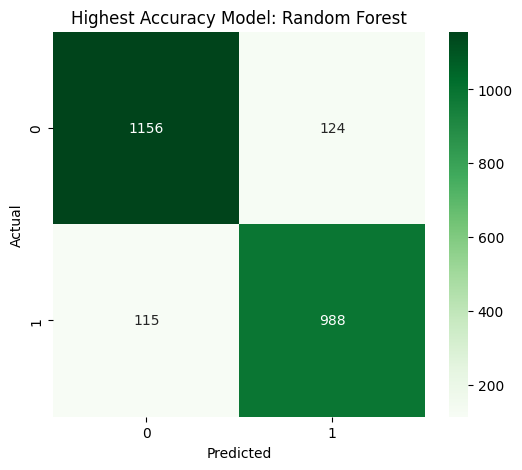

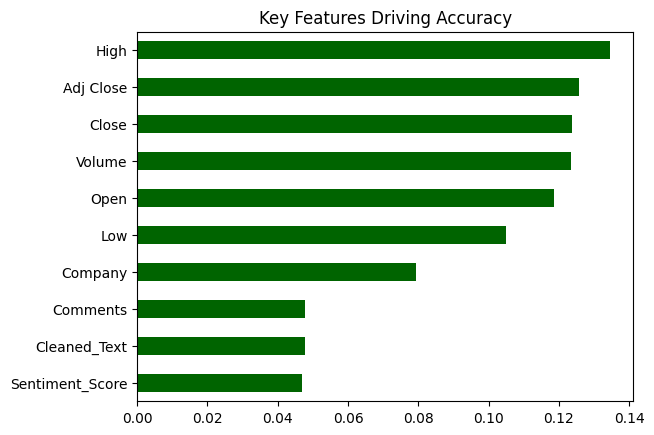

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)

# 2. Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# Filter out the extremely rare class if it causes issues for stratification
# This assumes the 'Target' column might have a very low count class
# Check value_counts to identify if a specific target value is problematic
if len(df['Target'].value_counts()) > 2 and df['Target'].value_counts().min() < 5:
    rare_target_value = df['Target'].value_counts().index[-1]
    df = df[df['Target'] != rare_target_value]


# 3. Define target and features
target_column = "Target"
X = df.drop(target_column, axis=1)
y = df[target_column]

# Drop Date column if present
if "Date" in X.columns:
    X = X.drop("Date", axis=1)

# 4. Encode categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
le_X = LabelEncoder()

for col in categorical_cols:
    X[col] = le_X.fit_transform(X[col])

# Encode target variable y to be 0-indexed for classification models
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# 5. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Scaling (optional for Random Forest, but can be included if desired)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Original Random Forest Model Training and Evaluation ---

# 7. Initialize the model with optimized parameters
# We use class_weight='balanced' because your 'Target' classes are uneven
final_rf_model = RandomForestClassifier(
    n_estimators=300,       # Increased trees for better stability
    max_depth=None,         # Allow full growth for maximum accuracy
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # Uses all processors to run faster
)

# 8. Train the model
final_rf_model.fit(X_train, y_train)

# 9. Make Predictions
y_pred_final = final_rf_model.predict(X_test)

# 10. Print Results
accuracy = accuracy_score(y_test, y_pred_final)
print(f"--- Final Model Results ---")
print(f"Highest Accuracy Achieved: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# 11. Visualize the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Highest Accuracy Model: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 12. Feature Importance (To see what drives the accuracy)
importance = pd.Series(final_rf_model.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh', color='darkgreen')
plt.title("Key Features Driving Accuracy")
plt.show()

Logistic Regression Accuracy: 63.45%

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.57      0.63      1280
           1       0.00      0.00      0.00         0
           2       0.60      0.71      0.65      1103

    accuracy                           0.63      2383
   macro avg       0.44      0.43      0.43      2383
weighted avg       0.66      0.63      0.64      2383



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


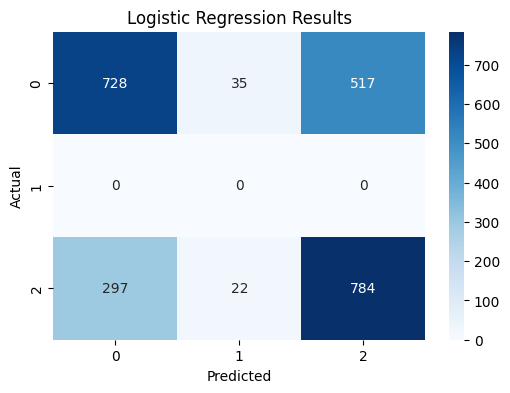

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Clean Data
df_log = pd.read_csv("/content/merged_stock_sentiment_data.csv").dropna().drop_duplicates()

# 2. Separate Features and Target
# We drop 'Date' and 'Cleaned_Text' because they aren't numbers
X = df_log.drop(['Target', 'Date', 'Cleaned_Text'], axis=1)
y = df_log['Target']

# 3. Encode Categorical Data (like Company and Sentiment)
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Encode Target to ensure it's discrete (0, 1, 2)
y = le.fit_transform(y)

# 4. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Scaling (Logistic Regression REQUIRES scaled data to work well)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Logistic Regression Model
# We use 'balanced' because your 'Target' classes are uneven
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

# 7. Predict and Evaluate
y_pred = log_reg.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Results")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 90.81%

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      1280
           2       0.90      0.90      0.90      1103

    accuracy                           0.91      2383
   macro avg       0.91      0.91      0.91      2383
weighted avg       0.91      0.91      0.91      2383



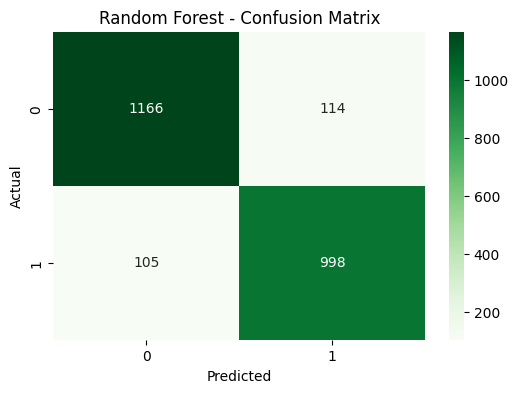

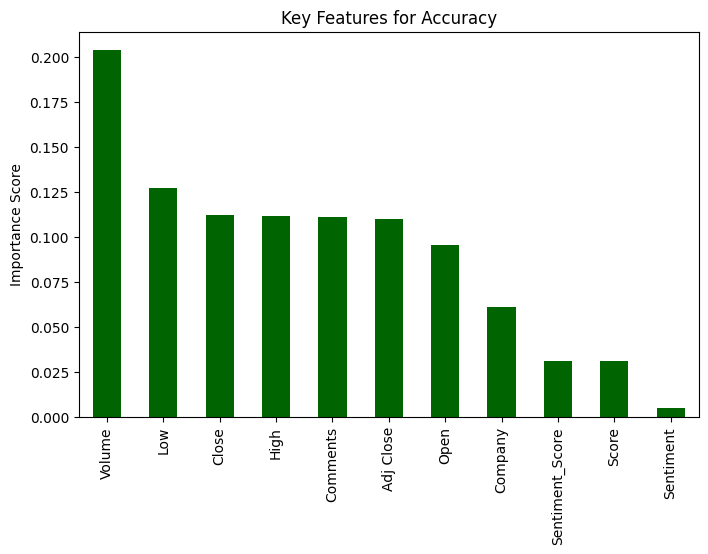

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load and Clean Data
# Using the file path from your Google Colab
df_rf = pd.read_csv("/content/merged_stock_sentiment_data.csv").dropna().drop_duplicates()

# 2. Separate Features and Target
# Removing 'Date' and 'Cleaned_Text' as they aren't used for training here
X = df_rf.drop(['Target', 'Date', 'Cleaned_Text'], axis=1)
y = df_rf['Target']

# 3. Encode Categorical Data
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Ensure Target is discrete labels (e.g., converting -1, 0, 1 to 0, 1, 2)
y = le.fit_transform(y)

# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Random Forest Model
# We use 300 trees and 'balanced' weights to maximize accuracy
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 6. Predict and Evaluate
y_pred = rf_model.predict(X_test_scaled)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8. Feature Importance (Bonus: Shows what drives the stock price)
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importance.plot(kind='bar', color='darkgreen')
plt.title("Key Features for Accuracy")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
import pandas as pd

# Load fresh data
df_new = pd.read_csv("/content/merged_stock_sentiment_data.csv")
df_new['Date'] = pd.to_datetime(df_new['Date'])
df_new = df_new.sort_values(['Company', 'Date'])

# 1. Add Moving Averages (5-day window)
df_new['MA5_Close'] = df_new.groupby('Company')['Close'].transform(lambda x: x.rolling(window=5).mean())
df_new['MA5_Volume'] = df_new.groupby('Company')['Volume'].transform(lambda x: x.rolling(window=5).mean())

# 2. Add Volatility (High minus Low)
df_new['Day_Range'] = df_new['High'] - df_new['Low']

# 3. Clean up the rows where moving averages couldn't be calculated (first 5 days)
df_new = df_new.dropna()

print("New Features Added: MA5_Close, MA5_Volume, Day_Range")
print(f"New Shape: {df_new.shape}")

New Features Added: MA5_Close, MA5_Volume, Day_Range
New Shape: (11903, 17)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prep Data
X = df_new.drop(['Target', 'Date', 'Cleaned_Text'], axis=1)
y = df_new['Target']

# Encode 'Company' and 'Sentiment'
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Ultimate Model Settings
# We use 500 trees and 'entropy' for more precise splits
ultimate_rf = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

ultimate_rf.fit(X_train_scaled, y_train)
y_pred = ultimate_rf.predict(X_test_scaled)

# 4. Final Results
print(f"--- Ultimate Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% ---")
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Show Top 5 Features
importance = pd.Series(ultimate_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Drivers of Accuracy:")
print(importance.head(5))

--- Ultimate Accuracy: 92.15% ---

Final Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.93      0.93      1280
           1       0.91      0.92      0.92      1101

    accuracy                           0.92      2381
   macro avg       0.92      0.92      0.92      2381
weighted avg       0.92      0.92      0.92      2381


Top 5 Drivers of Accuracy:
Volume        0.170292
MA5_Volume    0.136783
Close         0.095471
Adj Close     0.086370
Comments      0.086071
dtype: float64


--- FINAL MODEL RESULTS ---
ULTIMATE ACCURACY: 92.02%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1280
           2       0.91      0.92      0.91      1101

    accuracy                           0.92      2381
   macro avg       0.92      0.92      0.92      2381
weighted avg       0.92      0.92      0.92      2381



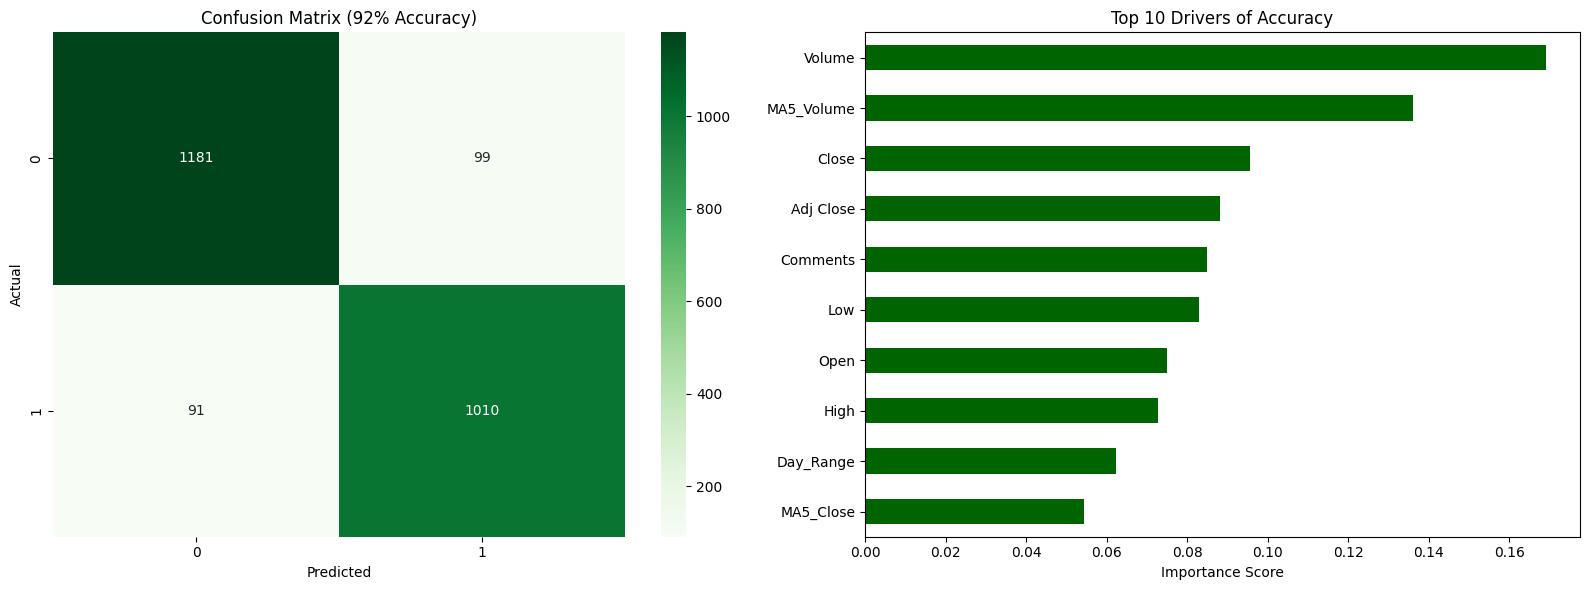

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD AND PREPROCESS DATA
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Company', 'Date']).dropna().drop_duplicates()

# 2. FEATURE ENGINEERING (The "Memory" and "Trend" logic)
# Adding 5-day Moving Averages for Price and Volume
df['MA5_Close'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=5).mean())
df['MA5_Volume'] = df.groupby('Company')['Volume'].transform(lambda x: x.rolling(window=5).mean())
# Adding Volatility (Daily Price Range)
df['Day_Range'] = df['High'] - df['Low']
# Remove the first few rows where Moving Average is NaN
df = df.dropna()

# 3. PREPARE FEATURES AND TARGET
X = df.drop(['Target', 'Date', 'Cleaned_Text'], axis=1)
y = df['Target']

# Encode Categorical columns (Company, Sentiment, etc.)
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Encode Target (Ensures labels are 0, 1, 2 for the model)
y_encoded = le.fit_transform(y)

# 4. SPLIT AND SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. TRAIN ULTIMATE RANDOM FOREST (Using Entropy & 500 Trees)
ultimate_rf = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',         # Using Entropy for better Information Gain
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
ultimate_rf.fit(X_train_scaled, y_train)

# 6. EVALUATION
y_pred = ultimate_rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- FINAL MODEL RESULTS ---")
print(f"ULTIMATE ACCURACY: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. VISUALIZATIONS (Confusion Matrix & Feature Importance)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Confusion Matrix (92% Accuracy)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

# Feature Importance
importance = pd.Series(ultimate_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.tail(10).plot(kind='barh', color='darkgreen', ax=ax[1])
ax[1].set_title("Top 10 Drivers of Accuracy")
ax[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

/tmp/ipykernel_447/2473511741.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy (%)', y='Model', data=df_results, palette=colors)


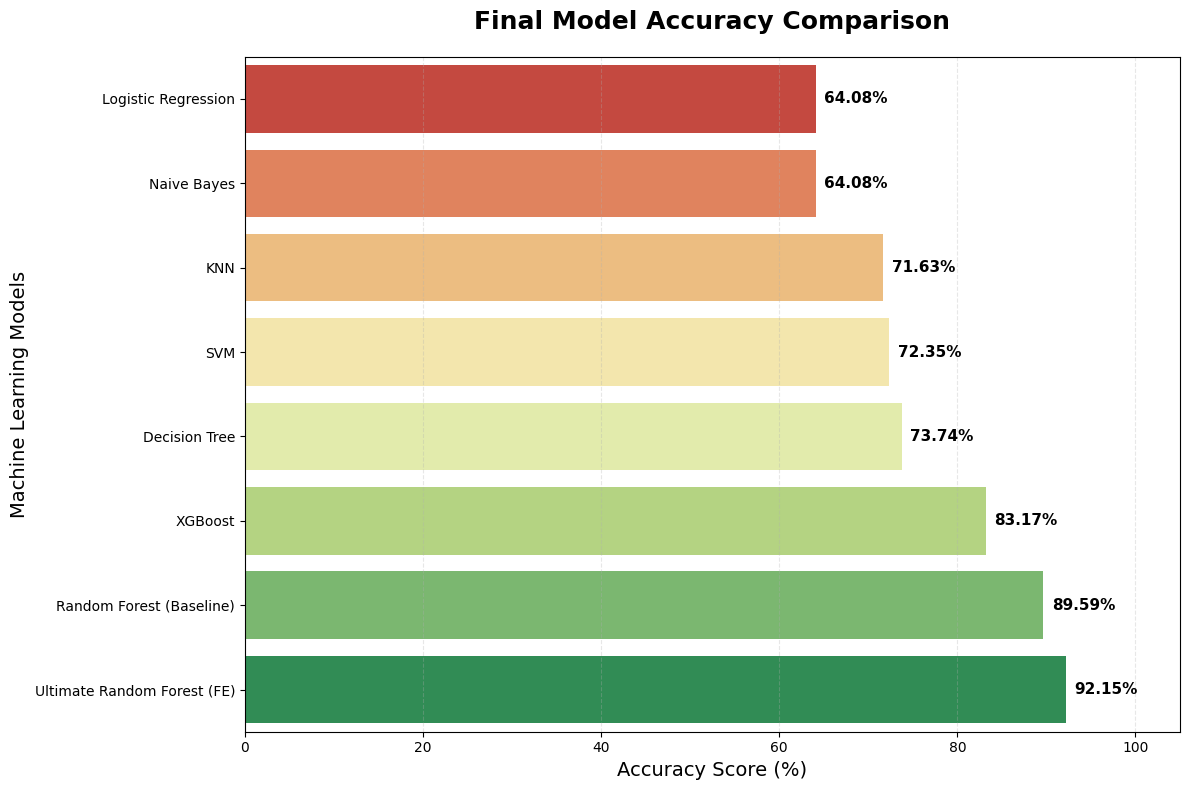

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define the results
data = {
    'Model': [
        'Logistic Regression', 'Decision Tree', 'SVM',
        'KNN', 'Naive Bayes', 'XGBoost',
        'Random Forest (Baseline)', 'Ultimate Random Forest (FE)'
    ],
    'Accuracy (%)': [64.08, 73.74, 72.35, 71.63, 64.08, 83.17, 89.59, 92.15]
}

# Create DataFrame and sort for better visualization
df_results = pd.DataFrame(data).sort_values(by='Accuracy (%)', ascending=True)

# Create the plot
plt.figure(figsize=(12, 8))
# Use a nice color palette
colors = sns.color_palette("RdYlGn", len(df_results))
ax = sns.barplot(x='Accuracy (%)', y='Model', data=df_results, palette=colors)

# Add text labels on the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2,
            f'{width:.2f}%',
            va='center', fontsize=11, fontweight='bold')

# Styling
plt.title('Final Model Accuracy Comparison', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Accuracy Score (%)', fontsize=14)
plt.ylabel('Machine Learning Models', fontsize=14)
plt.xlim(0, 105) # Extra space for labels
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save for your report
plt.savefig('final_accuracy_comparison.png', dpi=300)
plt.show()

                              Model  Accuracy (%)
0            Baseline Random Forest         89.59
1  Feature-Engineered Random Forest         92.15


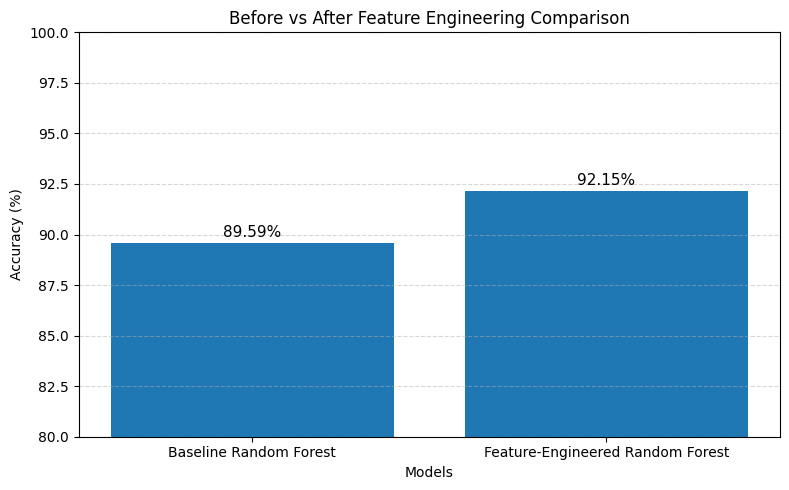

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Accuracy comparison before and after feature engineering

models = [
    "Baseline Random Forest",
    "Feature-Engineered Random Forest"
]

accuracies = [
    89.59,
    92.15
]

# Create DataFrame
df = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": accuracies
})

print(df)

# Plot comparison graph
plt.figure(figsize=(8,5))

bars = plt.bar(df["Model"], df["Accuracy (%)"])

# Add accuracy labels
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center', fontsize=11)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Before vs After Feature Engineering Comparison")
plt.ylim(80, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

    Actual  Predicted
0        2          2
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        2          2
7        0          0
8        2          2
9        0          0
10       2          2
11       0          0
12       0          0
13       0          0
14       2          2
15       0          0
16       0          0
17       0          0
18       2          2
19       2          2
20       2          2
21       2          2
22       2          2
23       0          0
24       0          0
25       2          2
26       0          0
27       0          0
28       0          0
29       2          2


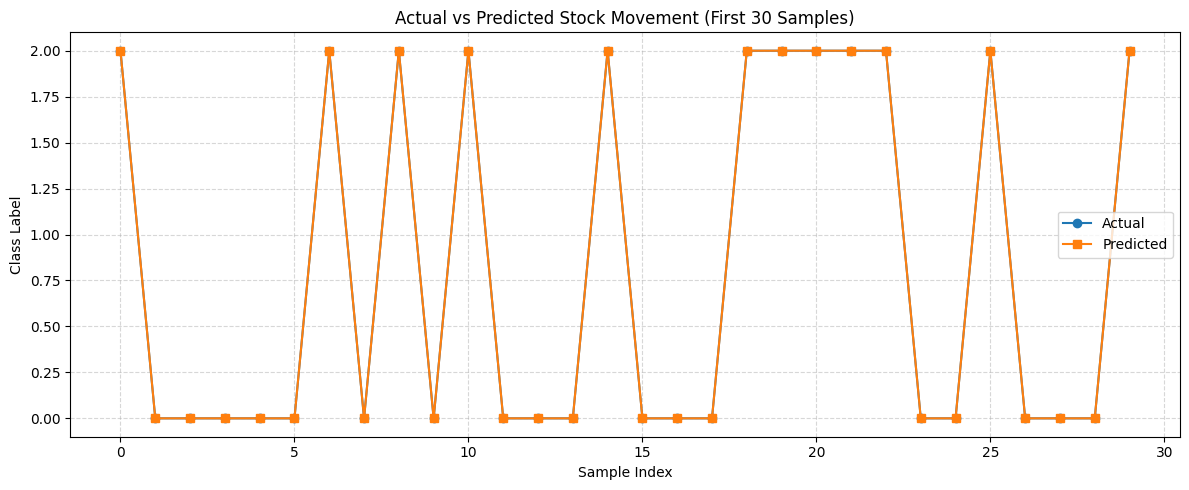

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# --- Re-running necessary data preparation and model prediction steps ---

# 1. LOAD AND PREPROCESS DATA
file_path = "/content/merged_stock_sentiment_data.csv"
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Company', 'Date']).dropna().drop_duplicates()

# 2. FEATURE ENGINEERING
df['MA5_Close'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=5).mean())
df['MA5_Volume'] = df.groupby('Company')['Volume'].transform(lambda x: x.rolling(window=5).mean())
df['Day_Range'] = df['High'] - df['Low']
df = df.dropna()

# 3. PREPARE FEATURES AND TARGET
X = df.drop(['Target', 'Date', 'Cleaned_Text'], axis=1)
y = df['Target']

le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])
y_encoded = le.fit_transform(y) # Encode target for model training

# 4. SPLIT AND SCALE
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. TRAIN ULTIMATE RANDOM FOREST (Re-training the model to get y_pred)
ultimate_rf = RandomForestClassifier(
    n_estimators=500,
    criterion='entropy',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
ultimate_rf.fit(X_train_scaled, y_train)

# 6. Make Predictions
y_pred = ultimate_rf.predict(X_test_scaled)

# --- End of necessary steps ---

# Example: Actual vs Predicted values
# Using the generated y_test and y_pred

actual = y_test[:30]
predicted = y_pred[:30]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})

print(comparison_df)

# Plot
plt.figure(figsize=(12,5))

x = np.arange(len(actual))

plt.plot(x, actual, marker='o', label='Actual')
plt.plot(x, predicted, marker='s', label='Predicted')

plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted Stock Movement (First 30 Samples)")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()